# Clase 01: ¿Por qué existen las estructuras de datos?

Curso intersemestral de **Estructuras de datos** para Matemáticas Aplicadas.

Idea central de la clase:

> Elegir una estructura de datos es elegir qué operaciones queremos hacer eficientes.

## Objetivos

Al terminar este notebook deberías poder:

- Explicar informalmente qué es una estructura de datos.
- Distinguir problema, representación de datos, algoritmo y resultado.
- Medir tiempos simples con `time.perf_counter`.
- Comparar búsqueda en `list` y `set`.
- Comparar conteo con `dict` y `Counter`.
- Conectar estructuras de datos con interfaces y métodos de Programación Orientada a Objetos.

## 1. Estructuras de datos, versión informal

Una **estructura de datos** es una forma de representar información para que ciertas operaciones sean naturales o eficientes.

Por ejemplo:

- Si quiero conservar orden, una `list` puede ser natural.
- Si quiero preguntar muchas veces si un valor aparece, un `set` puede ser más conveniente.
- Si quiero asociar una llave con un valor, un `dict` es natural.
- Si quiero contar frecuencias, `Counter` ya expresa esa intención.

In [2]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt

candidatos = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'clase_01']
raiz = next(
    candidato for candidato in candidatos
    if (candidato / 'src' / 'mediciones.py').exists()
)

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.mediciones import (
    buscar_en_conjunto,
    buscar_en_lista,
    contar_con_counter,
    contar_con_diccionario,
    generar_datos,
    medir_tiempo,
)

print('Listo: imports cargados correctamente.')

Listo: imports cargados correctamente.


## 2. Generar datos

Generaremos una lista de enteros con repeticiones. Las repeticiones nos servirán después para contar frecuencias.

In [3]:
n = 100_000
datos = generar_datos(n)

objetivo_presente = datos[-1]
objetivo_ausente = -1

print(f'Cantidad de datos: {len(datos):,}')
print(f'Primeros 10 datos: {datos[:10]}')
print(f'Objetivo presente: {objetivo_presente}')
print(f'Objetivo ausente: {objetivo_ausente}')

Cantidad de datos: 100,000
Primeros 10 datos: [1824, 409, 4506, 4012, 3657, 2286, 1679, 8935, 1424, 9674]
Objetivo presente: 1917
Objetivo ausente: -1


## 3. Medición básica con `time.perf_counter`

`time.perf_counter` sirve para medir intervalos cortos de tiempo. La idea básica es:

1. Tomar el tiempo inicial.
2. Ejecutar la operación.
3. Tomar el tiempo final.
4. Restar.

In [4]:
inicio = time.perf_counter()
resultado = buscar_en_lista(datos, objetivo_ausente)
fin = time.perf_counter()

print(f'¿Aparece el objetivo? {resultado}')
print(f'Tiempo: {fin - inicio:.6f} segundos')

¿Aparece el objetivo? False
Tiempo: 0.000992 segundos


### Pregunta

Si el valor no aparece en una lista, ¿cuántos elementos necesita revisar Python antes de estar seguro?

Debe revisarlos TODOS, pues el "in" funciona como un for interno que va iterando cada elemento de la lista hasta el final.

## 4. Búsqueda en lista

Una lista conserva orden y repeticiones. Para buscar pertenencia, Python puede necesitar recorrer muchos elementos.

In [5]:
tiempo_lista_presente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_presente),
    repeticiones=10,
)

tiempo_lista_ausente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_ausente),
    repeticiones=10,
)

print(f'Lista, objetivo presente: {tiempo_lista_presente:.6f} segundos')
print(f'Lista, objetivo ausente:  {tiempo_lista_ausente:.6f} segundos')

Lista, objetivo presente: 0.000033 segundos
Lista, objetivo ausente:  0.000679 segundos


## 5. Búsqueda en conjunto

Un conjunto (`set`) está diseñado para preguntas de pertenencia: `x in conjunto`.

Importante: convertir una lista a conjunto también cuesta. Por eso, si vamos a hacer muchas consultas, suele convenir construir el conjunto una vez y reutilizarlo.

In [6]:
conjunto = set(datos)

tiempo_set_presente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_presente),
    repeticiones=10,
)

tiempo_set_ausente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_ausente),
    repeticiones=10,
)

print(f'Conjunto, objetivo presente: {tiempo_set_presente:.8f} segundos')
print(f'Conjunto, objetivo ausente:  {tiempo_set_ausente:.8f} segundos')
print(f'Tamaño de la lista: {len(datos):,}')
print(f'Tamaño del conjunto: {len(conjunto):,}')

Conjunto, objetivo presente: 0.00000037 segundos
Conjunto, objetivo ausente:  0.00000018 segundos
Tamaño de la lista: 100,000
Tamaño del conjunto: 10,000


### Preguntas

1. ¿Por qué el conjunto puede tener menos elementos que la lista?

Porque en el conjunto, si tienes un elemento repetidas veces, solo aparecerá una sola vez, a diferencia que en la lista, que puede haber el mismo elementos las veces que sean 

2. ¿Qué información conserva la lista que el conjunto ya no representa de la misma forma?

La frecuencia

3. Si solo te importa saber si un valor aparece, ¿qué estructura parece más natural?

El conjunto, pues no te importa cuántas veces aparece, sino solo te importa si aparece o no

## 6. Comparar varios tamaños

Ahora repetimos la medición con distintos tamaños. Usaremos un objetivo ausente para forzar el peor caso típico en una lista.

In [7]:
tamanos = [1_000, 10_000, 50_000, 100_000, 200_000]
tiempos_lista = []
tiempos_set = []

for tamano in tamanos:
    muestra = generar_datos(tamano)
    conjunto_muestra = set(muestra)
    ausente = -1

    t_lista = medir_tiempo(lambda: buscar_en_lista(muestra, ausente), repeticiones=8)
    t_set = medir_tiempo(lambda: buscar_en_conjunto(conjunto_muestra, ausente), repeticiones=8)

    tiempos_lista.append(t_lista)
    tiempos_set.append(t_set)

print('tamaño      lista (s)      set (s)')
for tamano, t_lista, t_set in zip(tamanos, tiempos_lista, tiempos_set):
    print(f'{tamano:>7,}   {t_lista:>11.8f}   {t_set:>11.8f}')

tamaño      lista (s)      set (s)
  1,000    0.00000810    0.00000026
 10,000    0.00007834    0.00000035
 50,000    0.00036383    0.00000053
100,000    0.00068191    0.00000044
200,000    0.00118766    0.00000043


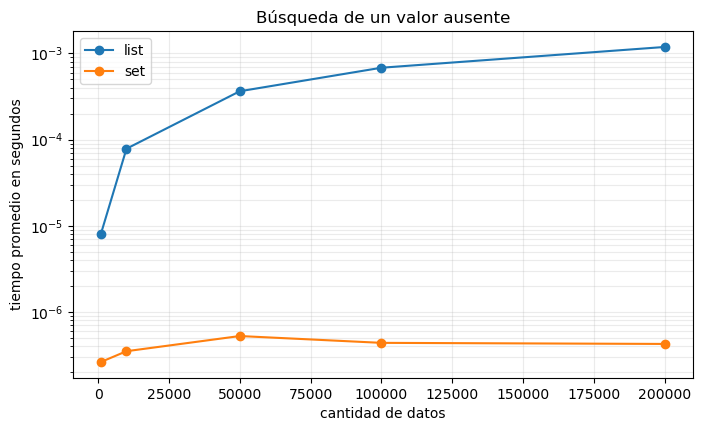

In [8]:
plt.figure(figsize=(8, 4.5))
plt.plot(tamanos, tiempos_lista, marker='o', label='list')
plt.plot(tamanos, tiempos_set, marker='o', label='set')
plt.yscale('log')
plt.xlabel('cantidad de datos')
plt.ylabel('tiempo promedio en segundos')
plt.title('Búsqueda de un valor ausente')
plt.grid(True, which='both', alpha=0.25)
plt.legend()
plt.show()

### Interpretación

Escribe una conclusión breve:

- ¿Qué curva crece más rápido?

La de la lista

- ¿Qué operación queríamos hacer eficiente?

La operación de saber si un objeto aparece o no en un iterable

- ¿Qué costo pagamos antes de poder buscar en un conjunto?

pagamos el costo de transformar la lista a un conjunto

## 7. Conteo con diccionario

Para contar frecuencias, una representación natural es:

$$\text{valor} \mapsto \text{frecuencia}$$

En Python, esto se puede representar con un diccionario.

In [9]:
conteos_dict = contar_con_diccionario(datos)

print(f'Valores distintos: {len(conteos_dict):,}')
print('Primeros 10 pares valor -> frecuencia:')
for valor, frecuencia in list(conteos_dict.items())[:10]:
    print(f'{valor:>5} -> {frecuencia}')

Valores distintos: 10,000
Primeros 10 pares valor -> frecuencia:
 1824 -> 8
  409 -> 8
 4506 -> 14
 4012 -> 9
 3657 -> 15
 2286 -> 15
 1679 -> 8
 8935 -> 4
 1424 -> 11
 9674 -> 10


## 8. Conteo con `Counter`

`Counter` es una clase de la biblioteca estándar diseñada para conteos. Es útil cuando el problema ya es claramente un problema de frecuencias.

In [10]:
conteos_counter = contar_con_counter(datos)

print('Los 10 valores más frecuentes:')
for valor, frecuencia in conteos_counter.most_common(10):
    print(f'{valor:>5} -> {frecuencia}')

assert dict(conteos_counter) == conteos_dict
print('El diccionario y Counter contienen las mismas frecuencias.')

Los 10 valores más frecuentes:
 7289 -> 24
 7779 -> 23
 4009 -> 22
 9697 -> 21
 2001 -> 21
  897 -> 21
 9376 -> 21
 5269 -> 21
 3519 -> 21
  848 -> 21
El diccionario y Counter contienen las mismas frecuencias.


## 9. Comparar `dict` y `Counter`

Ambas opciones representan conteos. La diferencia no es solo de tiempo: también importa la claridad de la intención.

In [18]:
tiempo_dict = medir_tiempo(lambda: contar_con_diccionario(datos), repeticiones=5)
tiempo_counter = medir_tiempo(lambda: contar_con_counter(datos), repeticiones=5)

print(f'Diccionario manual: {tiempo_dict:.6f} segundos')
print(f'Counter:            {tiempo_counter:.6f} segundos')

Diccionario manual: 0.007370 segundos
Counter:            0.003277 segundos


### Preguntas

1. ¿Qué hace explícito el diccionario manual?

Toma cada valor de la lista datos y verifica si ya está en el diccionario, si ya está, solo le suma uno al conteo; si no está, primero crea una llave con tal valor iniciada en cero, y después de suma uno al contador. Así hasta terminar con la lista

2. ¿Qué hace más cómodo `Counter`?

Que ya es una clase predeterminada hecha, por lo que no debes de programar nada extra, y además ya trae consigo métodos muy útiles, como es el de ".most_common"

3. ¿Cuál usarías en una librería educativa? ¿Por qué?

Ambas, pues primero yo creo que es necesario definir el conteo por diccionario por mero objetivo didáctico, para después usar solamente Counter, pues es mucho más útil

## 10. Problema, representación, algoritmo y resultado

Completa mentalmente o por escrito esta tabla para un problema propio de Matemáticas Aplicadas.

| Elemento | Ejemplo: conteo de datos | Tu ejemplo: Una red social pequeña |
| --- | --- | --- |
| Problema | Encontrar frecuencias | Cómo saber quién tiene amistad con quién |
| Representación | Diccionario valor -> frecuencia | Diccionario valor -> Booleano  |
| Algoritmo | Recorrer datos y actualizar conteos | Recorrer el diccionario buscando el usuario que preguntas y ver si en sus valores está el otro usuario|
| Resultado | Tabla de frecuencias | Valor Booleano que dice si hay amistad entre usuario 1 y usuario 2 |
| Operación eficiente | Actualizar o consultar una frecuencia | Agregar o eliminar amistades |

## 11. Ejercicio guiado

Cambia `n_ejercicio` y observa cómo cambian los tiempos. Mantén el objetivo ausente para comparar el peor caso típico de búsqueda en lista.

In [58]:
n_ejercicio = 1234321
datos_ejercicio = generar_datos(n_ejercicio)
conjunto_ejercicio = set(datos_ejercicio)
objetivo = -1

tiempo_lista = medir_tiempo(lambda: buscar_en_lista(datos_ejercicio, objetivo), repeticiones=10)
tiempo_set = medir_tiempo(lambda: buscar_en_conjunto(conjunto_ejercicio, objetivo), repeticiones=10)

print(f'n = {n_ejercicio:,}')
print(f'lista: {tiempo_lista:.8f} segundos')
print(f'set:   {tiempo_set:.8f} segundos')

n = 1,234,321
lista: 0.00769089 segundos
set:   0.00000035 segundos


## 12. Conexión con Programación Orientada a Objetos

En POO ya trabajaste con clases, atributos y métodos. Una estructura de datos también se puede pensar como un objeto con una **interfaz**:

- Qué operaciones ofrece.
- Qué promete cada operación.
- Qué detalles internos quedan ocultos.

Por ejemplo, una pila puede ofrecer `push`, `pop`, `peek` e `is_empty`, aunque internamente pueda guardarse de distintas formas.

## 13. Reflexión final

Responde con tus palabras:

1. ¿Por qué existen las estructuras de datos?

Existen para poder tener mayor eficiencia en recursos y en tiempo para realizar operaciones con datos masivos. Así como para llevar mayor claridad y orden al trabajar con datos.

2. ¿Qué significa que una operación sea natural para una estructura?

Que es intuitiva, que no es necesario darle una profunda explicación pues es común que a cualquier persona se le ocurra

3. ¿Qué estructura usarías para representar amistades en una red social?

un Diccionario, pues cada llave sería el usuario, y sus valores con quiénes está asociado en amistades

4. ¿Qué estructura usarías para representar rutas en una ciudad?

Un diccionario de diccionarios de listas, pues cada llave del diccionario global sería cuáles son los distintos destinos a los que puedes ir. Después dentro de cada llave, los valores serían diccionarios donde cada llave sería cuánto tiempo estimado tardarías en llegar ahí. Finalmente el valor del diccionario sería una lista con las instrucciones en orden a seguir para llegar ahí.

5. ¿Cómo se conecta todo esto con el proyecto colaborativo del curso?

Se conecta de forma que cada uno de nosotros tendrá datos diferentes y nuevos cada vez que trabajemos por nuestra cuenta, y al cabo de todo el mes tendríamos muchísimos datos, datos que tendríamos qué saber como organizarlos para hacer el proyecto correctamente.

## 14. Reto opcional

Medir solo la búsqueda en un conjunto puede esconder el costo de construirlo. En este reto medimos el costo total de:

1. Convertir la lista a conjunto.
2. Hacer muchas consultas de pertenencia.

Pregunta: ¿a partir de cuántas consultas empieza a convenir construir el conjunto?

Yo considero que realmente empieza a convenir a partir de que hay más de una consulta. Pues si es solo una, es el mismo costo el convertir a conjunto y luego buscar en él, que solamente buscar en la lista; sin embargo si vamos a hacer más de una vez la consulta, entonces conviene convertir a conjunto una sola vez y después solamente consultar cada vez en el conjunto.

In [59]:
def medir_muchas_consultas_en_lista(datos, consultas):
    inicio = time.perf_counter()
    for objetivo in consultas:
        objetivo in datos
    return time.perf_counter() - inicio


def medir_muchas_consultas_en_set(datos, consultas):
    inicio = time.perf_counter()
    conjunto = set(datos)
    for objetivo in consultas:
        objetivo in conjunto
    return time.perf_counter() - inicio


datos_reto = generar_datos(30_000)

for cantidad_consultas in [1, 10, 100, 500, 1_000]:
    consultas = [-1 - i for i in range(cantidad_consultas)]
    t_lista = medir_muchas_consultas_en_lista(datos_reto, consultas)
    t_set = medir_muchas_consultas_en_set(datos_reto, consultas)
    print(f'{cantidad_consultas:>5,} consultas | lista: {t_lista:.5f}s | set total: {t_set:.5f}s')

    1 consultas | lista: 0.00027s | set total: 0.00041s
   10 consultas | lista: 0.00243s | set total: 0.00044s
  100 consultas | lista: 0.02342s | set total: 0.00038s
  500 consultas | lista: 0.10689s | set total: 0.00051s
1,000 consultas | lista: 0.20555s | set total: 0.00046s


## Preguntas finales práctica

1. ¿Por qué una lista no siempre es la mejor representación?

Porque puede ser que en la lista se repitan muchísimos valores, y al querer comprobar si hay un elemnto presente en la lista, al haber muchos repetidos, estarías revisando dobles muchas veces y eso es ineficiente.

2. ¿Qué ganamos al cambiar de lista a conjunto?

Hacer que los elementos que se repetían solo aparezcan una vez y así comprobar solo una vez si nuesto valor buscado es ese. Ganamos eficiencia en tiempo y recursos

3. ¿Qué se pierde o cambia cuando usamos un conjunto?

Se pierde el dato de la frecuencia

4. ¿Por qué un diccionario es natural para contar?

Porque así emparejas a cada valor de tus datos con un número específico, creando una relación uno a uno

5. ¿Qué relación ves entre estructuras de datos y Programación Orientada a Objetos?

Veo que sería muy util meter tus datos a objetos para clasificarlos y para tener métodos hechos para trabajar con los datos